In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 80
T2 = 80

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qubit")

In [3]:
# building the gates 
dim = 2
# encoding gates 
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

# rotation gates
z_gate = qt.rz(-np.pi / 2)
h_gate = 1/np.sqrt(2) * qt.Qobj([[1,1],[1,-1]])
x_gate = qt.Qobj([[0, 1],[1, 0]])

# set of iswaps
iswap1 = qt.iswap(N=5, targets=[0,3])
iswap2 = qt.iswap(N=5, targets=[0,1])
iswap3 = qt.iswap(N=5, targets=[0,4])
iswap4 = qt.iswap(N=5, targets=[0,2])

swap1 = qt.swap(N=5, targets=[0,3])
swap2 = qt.swap(N=5, targets=[0,1])
swap3 = qt.swap(N=5, targets=[0,4])
swap4 = qt.swap(N=5, targets=[0,2])
swap5 = qt.swap(N=5, targets=[1,4])

first_cnot = [
    tensor(tensor([qt.qeye(dim)] * 3), h_gate, qt.qeye(dim)),
    tensor(z_gate, tensor([qt.qeye(dim)] * 2), z_gate, qt.qeye(dim)),
    iswap1,
    tensor(z_gate, tensor([qt.qeye(dim)] * 4))
]
second_cnot = [
    tensor(h_gate, tensor([qt.qeye(dim)] * 4)),
    tensor(z_gate, z_gate, tensor([qt.qeye(dim)] * 3)),
    iswap2,
    tensor(qt.qeye(dim), z_gate, tensor([qt.qeye(dim)] * 3))
]
third_cnot = [
    tensor(tensor([qt.qeye(dim)] * 4), h_gate),
    tensor(z_gate, tensor([qt.qeye(dim)] * 3), z_gate),
    iswap3,
    tensor(z_gate, tensor([qt.qeye(dim)] * 4))
]
fourth_cnot = [
    tensor(h_gate, tensor([qt.qeye(dim)] * 4)),
    tensor(z_gate, qt.qeye(dim), z_gate, tensor([qt.qeye(dim)] * 2)),
    iswap4,
    tensor(tensor([qt.qeye(dim)] * 2), z_gate, tensor([qt.qeye(dim)] * 2))
]

time_cnot = [.025, .025, .25, .025]
cnot_list = [first_cnot, second_cnot, third_cnot, fourth_cnot]

C:\Users\girgi\AppData\Local\Temp\ipykernel_7332\3272855060.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_7332\3272855060.py:5: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_7332\3272855060.py:8: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [4]:
len(time_cnot) == len(first_cnot)

True

In [5]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [6]:
# have to have some way of comparing the states easiest way is to apply an instant swap but finish the circuit first
filtered_states = []

In [7]:
# run the circuit 
unfiltered_states = []
# for i in range(len(cnot_list)):
for j in range(len(time_cnot)):
    rho_evo = trotter.apply(rho=rho_encoded, duration=time_cnot[j], unitary=[cnot_list[0][j]])
    unfiltered_states.extend(rho_evo)
    # filtered_states.append(swap1 * unfiltered_states[-1] * swap1.dag())
for j in range(len(time_cnot)):
    rho_evo = trotter.apply(rho=unfiltered_states[-1], duration=time_cnot[j], unitary=[cnot_list[1][j]])
    unfiltered_states.extend(rho_evo)
    # filtered_states.append(swap2 * unfiltered_states[-1] * swap2.dag())
for j in range(len(time_cnot)):
    rho_evo = trotter.apply(rho=unfiltered_states[-1], duration=time_cnot[j], unitary=[cnot_list[2][j]])
    unfiltered_states.extend(rho_evo)
    # filtered_states.append(swap3 * unfiltered_states[-1] * swap3.dag())
for j in range(len(time_cnot)):
    rho_evo = trotter.apply(rho=unfiltered_states[-1], duration=time_cnot[j], unitary=[cnot_list[3][j]])
    unfiltered_states.extend(rho_evo)    
    # filtered_states.append(swap4 * unfiltered_states[-1] * swap4.dag())


In [8]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [tensor(qt.qeye(dim), tensor(basis(dim, i), basis(dim, j)) * tensor(basis(dim, i), basis(dim, j)).dag(), tensor([qt.qeye(dim)] * 2)) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * unfiltered_states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * unfiltered_states[-1] * proj.dag() / (proj * unfiltered_states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(x_gate, qt.qeye(dim), qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(qt.tensor([qt.qeye(dim)] * 3), x_gate, qt.qeye(dim))
r11 = qt.tensor(tensor([qt.qeye(dim)] * 4), x_gate)
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .025
recovery_states = []

for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=[recovery_ops[i]])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    current_state = sum(current_state)/(sum(current_state)).tr()
    unfiltered_states.append(current_state)
    # filtered_states.append(swap5 * swap1 * swap4 * current_state * swap4.dag() * swap1.dag() * swap5.dag())
    # fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

total_time = 4 * sum(time_cnot) + duration_recovery

[0.25076267412969455, 0.250400390541478, 0.24959876885910195, 0.24923816646972552]


In [9]:
# qt.ptrace(unfiltered_states[-1], [4,3,0])

[0.0006574487180524961, 0.24973303910636352, 0.0006388252931300293, 0.0006571248171866189, 0.250136475139387, 0.0006672778629504672, 0.248959920105286, 0.24854988895764396]


Text(0.5, 0, 'time (dt)')

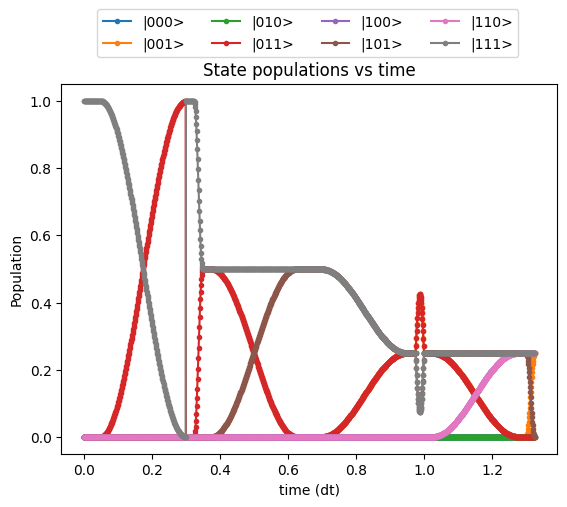

In [10]:
time = np.linspace(0, total_time, len(unfiltered_states))
# time = np.linspace(0, total_time, len(filtered_states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    for j in range(len(unfiltered_states)):
        data.append(np.real(qt.ptrace(unfiltered_states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")